In [1]:
import nltk
from nltk.tokenize import sent_tokenize
nltk.download('punkt')
from sklearn.feature_extraction.text import TfidfVectorizer

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [2]:
sentence2 = """Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.

Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.

Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.

"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 2025.

Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. Buka peluang investasi sektor strategis
Dana tersebut akan difokuskan pada peluang investasi di berbagai sektor strategis, antara lain hilirisasi, kesehatan, energi terbarukan, teknologi, serta sektor-sektor lain yang dipandang relevan oleh pengelola dana.

"Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.

Lebih lanjut, Rosan menegaskan, kolaborasi ini menjadi bukti kepercayaan dunia internasional terhadap kapasitas kelembagaan Indonesia dalam mengelola investasi berskala besar.

"Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qatar. Ini menunjukkan bahwa Indonesia tidak hanya menjadi tujuan investasi, tetapi juga memiliki kapasitas kelembagaan yang mumpuni untuk mengelola nvestasi secara profesional dan akuntabel," ungkapnya.

Inisiatif co-partnership dan perluasan kerja sama strategis ini diharapkan tidak hanya memperkuat hubungan diplomatik kedua negara, tetapi juga memberikan kontribusi nyata terhadap percepatan pembangunan ekonomi dan peningkatan kesejahteraan masyarakat Indonesia. Jangan lupa ikuti update berita lainnya dan follow  akun
Google News Metrotvnews.com dan Channel WhatsApp Metro TV

(Eko Nordiansyah)"""

In [3]:
import nltk
from nltk.tokenize import sent_tokenize

# Download the 'punkt_tab' data
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print(sent_token2)

['Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.', 'Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.', 'Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.', 'Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.', 'Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.', '"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 April 20

In [5]:
!pip install Sastrawi


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)
print("Tokenized sentences:")
for sent in sent_token2:
    print(sent)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]
print("\nCleaned sentences (Indonesian stop words removed):")
for clean_sent in cleaned_sentences:
    print(clean_sent)

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

print("\nTF-IDF Feature Matrix (Sparse) on cleaned sentences:")
print(features)

print("\nShape of the Feature Matrix (Number of sentences, Number of unique words after Indonesian stop word removal):")
print(features.shape)

# Feature names
feature_names = vectorizer.get_feature_names_out()
print("\nFeature Names (Words in the vocabulary after Indonesian stop word removal):")
print(feature_names)

# TF-IDF untuk kalimat pertama
if cleaned_sentences:
    first_cleaned_sentence_tfidf = features[0].toarray()
    print("\nTF-IDF values for the first cleaned sentence:")
    print(first_cleaned_sentence_tfidf)

    import pandas as pd
    def get_tfidf_for_sentence(tfidf_matrix, sentence_index, feature_names):
        sentence_tfidf_values = tfidf_matrix[sentence_index].toarray().flatten()
        tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf_values})
        tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values(by='TF-IDF', ascending=False)
        return tfidf_df

    first_cleaned_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)
    print("\nTF-IDF values for the first cleaned sentence (sorted):")
    print(first_cleaned_sentence_tfidf_df)
else:
    print("\nNo cleaned sentences to process.")

Tokenized sentences:
Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
"Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertulis, Selasa, 15 Apri

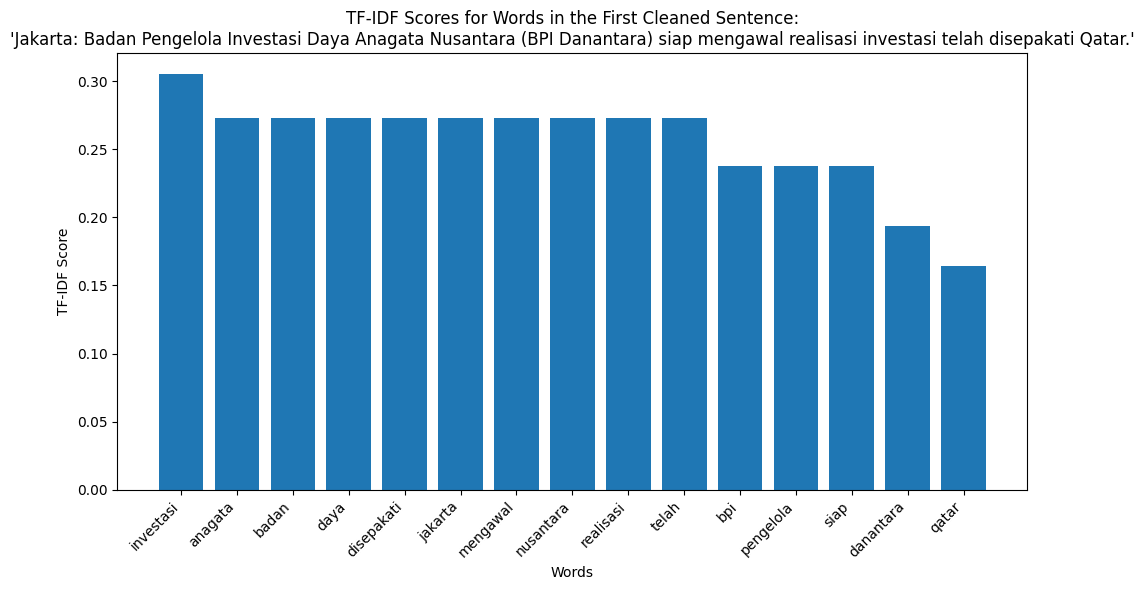

In [7]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt
import pandas as pd

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

# Get TF-IDF scores for the first cleaned sentence
if cleaned_sentences:
    first_cleaned_sentence = cleaned_sentences[0]
    first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

    # Visualisasi
    plt.figure(figsize=(10, 6))
    plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.title(f"TF-IDF Scores for Words in the First Cleaned Sentence:\n'{first_cleaned_sentence}'")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No cleaned sentences to visualize.")

**List of Sentences:**
1. Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
2. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
3. Pemerintah Republik Indonesia dan Pemerintah Qatar menggelar diskusi untuk menyepakati kemitraan strategis (co-partnership) dalam pengelolaan dana investasi untuk Indonesia yang akan berfokus di berbagai sektor pembangunan.
4. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
5. Dana ini akan difokuskan pada pengembangan berbagai sektor di antaranya termasuk tapi tidak terbatas pada hilirisasi industri, energi terbarukan, dan fasilitas kesehatan di Indonesia.
6. "Kami menyambut baik kepercayaan yang diberikan oleh Pemerintah Qatar melalui pembentukan dana bersama ini," kata CEO Danantara Indonesia Rosan Perkasa Roeslani dalam keterangan tertu

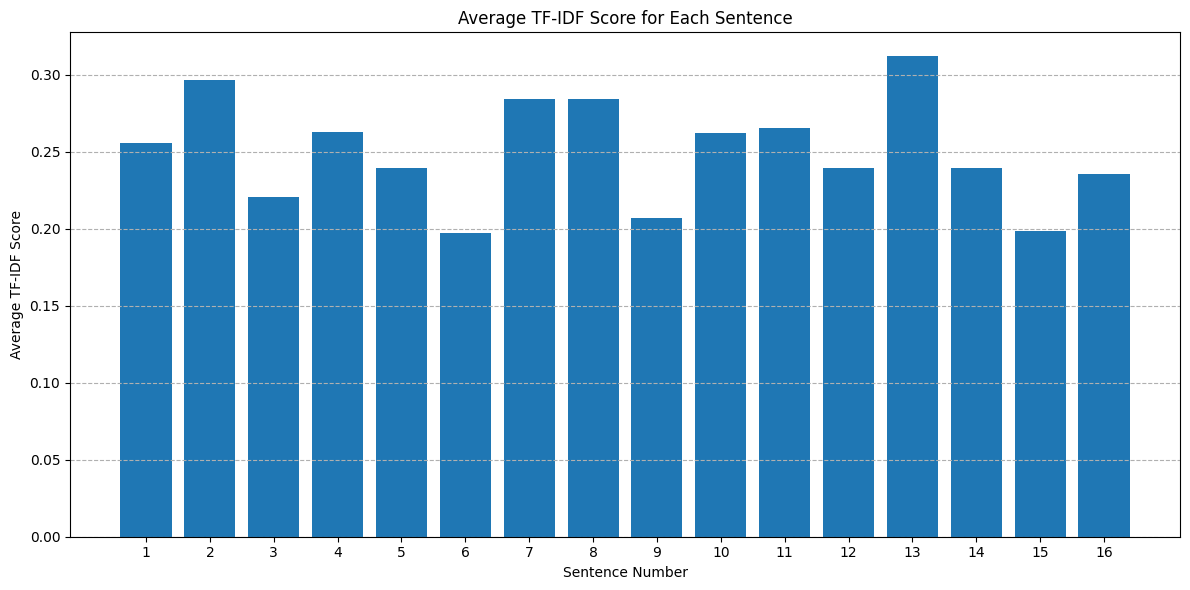

In [8]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import matplotlib.pyplot as plt

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer on the cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Variable initialization
sent_index = 0
sent_scores = []

# Calculate sentence TF-IDF score and list sentences
print("**List of Sentences:**")
for i, sent in enumerate(sent_token2):
    print(f"{i + 1}. {sent}")
print("\n-------------------------")

# Calculate average TF-IDF score for each sentence
print("\n**Average TF-IDF Score for Each Sentence:**")
for i in features:
    print(f"- Sentence {sent_index + 1}")
    sent_score = i.sum()
    sent_length = len(i.data)
    print("  Sum of TF-IDF scores:", sent_score)
    print("  Number of words:", sent_length)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    print("  Average TF-IDF score:", avg_score)
    sent_scores.append(avg_score)
    sent_index += 1
print("\n-------------------------")

print("\nList of average TF-IDF scores for each sentence:")
print(sent_scores)

# Visualisasi
plt.figure(figsize=(12, 6))
plt.bar(range(1, len(sent_scores) + 1), sent_scores)
plt.xlabel("Sentence Number")
plt.ylabel("Average TF-IDF Score")
plt.title("Average TF-IDF Score for Each Sentence")
plt.xticks(range(1, len(sent_scores) + 1))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()

In [9]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Sentence tokenization
sent_token2 = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words from each sentence
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token2]

# Training TF-IDF Vectorizer
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Hitung skor tiap kalimat
sent_scores = []
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Hitung threshold (rata-rata semua skor kalimat)
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0

print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.24996411348685135


In [11]:
import nltk
from nltk.tokenize import word_tokenize
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Bersihkan semua kalimat
all_cleaned_sentences = []
for sentence in sentence2:
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)

# TF
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# IDF
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(
        1 for doc in all_documents if term.lower() in word_tokenize(doc.lower())
    )
    return math.log(len(all_documents) / num_documents_with_term) if num_documents_with_term > 0 else 0

# TF-IDF kata "investasi"
tfidf_scores = {}
for i, sentence in enumerate(sentence2):
    cleaned_sentence = stopword_remover.remove(sentence)
    tf = calculate_tf("investasi", cleaned_sentence)
    idf = calculate_idf("investasi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

# Output
print("TF-IDF Score for 'investasi' in each cleaned sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# IDF keseluruhan
overall_idf_investasi = calculate_idf("investasi", all_cleaned_sentences)
print(f"\nOverall IDF for 'investasi': {overall_idf_investasi:.4f}")

KeyboardInterrupt: 

In [41]:
#threshold = sum(sent_scores)/len(sent_scores) # Average of Sentence Scores
#threshold

# Get Sentences

Pada bagian ini, sistem membuat ringkasan otomatis dari teks menggunakan metode TF-IDF.

Setiap kalimat diberikan skor berdasarkan rata-rata nilai TF-IDF dari kata-kata di dalamnya. Kemudian dihitung nilai threshold, yaitu rata-rata dari seluruh skor kalimat.

Kalimat yang memiliki skor lebih besar atau sama dengan threshold akan dipilih sebagai bagian dari ringkasan.

Semua kalimat terpilih kemudian digabungkan untuk membentuk ringkasan akhir.

In [42]:
import nltk
from nltk.tokenize import sent_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Sentence tokenization
sent_token = sent_tokenize(sentence2)

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# Remove stop words
cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token]

# TF-IDF
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)

# Hitung skor kalimat
sent_scores = []
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Threshold
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print("Threshold (Average of Sentence Scores):", threshold)

# Summary
final_summ = ""

print("\n**Summary Sentences (above or equal to the threshold):**")
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print(f"- {sent_token[index]}")

print("\n**Final Summary:**")
print(final_summ.strip())

Threshold (Average of Sentence Scores): 0.24996411348685135

**Summary Sentences (above or equal to the threshold):**
- Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
- Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
- Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
- Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
- Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
- "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
- Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian na

Pada kode ini, dilakukan dua cara perhitungan TF-IDF untuk kata “investasi”, yaitu secara manual dan menggunakan library TfidfVectorizer.

Pada metode manual:

* TF dihitung dari frekuensi kata dalam kalimat
* IDF dihitung dari kemunculan kata di seluruh kalimat
* TF dan IDF dikalikan untuk mendapatkan nilai TF-IDF

Kemudian, hasil tersebut dibandingkan dengan perhitungan menggunakan *TfidfVectorizer* dari scikit-learn.

Tujuan dari perbandingan ini adalah untuk memahami bagaimana TF-IDF bekerja secara konsep, sekaligus melihat implementasi praktis menggunakan library.

In [43]:
import nltk
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
import math

# Initialize Indonesian StopWordRemover
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

# TF
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

# IDF
def calculate_idf(term, all_documents):
    num_documents_with_term = sum(
        1 for doc in all_documents if term.lower() in word_tokenize(doc.lower())
    )
    return math.log(len(all_documents) / num_documents_with_term) if num_documents_with_term > 0 else 0

# TF-IDF manual
tfidf_scores = {}
all_cleaned_sentences = []

for i, sentence in enumerate(sentences):
    cleaned_sentence = stopword_remover.remove(sentence)
    all_cleaned_sentences.append(cleaned_sentence)
    tf = calculate_tf("investasi", cleaned_sentence)
    idf = calculate_idf("investasi", all_cleaned_sentences)
    tfidf = tf * idf
    tfidf_scores[f"Sentence {i+1}"] = tfidf

print("TF-IDF Score for 'investasi' in each sentence:")
for sentence_num, score in tfidf_scores.items():
    print(f"{sentence_num}: {score:.4f}")

# IDF keseluruhan
overall_idf_investasi = calculate_idf("investasi", all_cleaned_sentences)
print(f"\nOverall IDF for 'investasi': {overall_idf_investasi:.4f}")

# TF-IDF pakai sklearn
vectorizer = TfidfVectorizer(stop_words=factory.get_stop_words())
tfidf_matrix = vectorizer.fit_transform(sentences)
feature_names = vectorizer.get_feature_names_out()

try:
    investasi_index = list(feature_names).index("investasi")
    print("\nTF-IDF Score for 'investasi' using TfidfVectorizer:")
    for i, sentence in enumerate(sentences):
        tfidf = tfidf_matrix[i, investasi_index]
        print(f"Sentence {i+1}: {tfidf:.4f}")
except ValueError:
    print("\n'investasi' not found in the vocabulary after stop word removal by TfidfVectorizer.")

TF-IDF Score for 'investasi' in each sentence:
Sentence 1: 0.0000
Sentence 2: 0.0000
Sentence 3: 0.0176
Sentence 4: 0.0192
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.0523
Sentence 10: 0.0385
Sentence 11: 0.0000
Sentence 12: 0.0347
Sentence 13: 0.0000
Sentence 14: 0.0330
Sentence 15: 0.0000
Sentence 16: 0.0000

Overall IDF for 'investasi': 0.8267

TF-IDF Score for 'investasi' using TfidfVectorizer:
Sentence 1: 0.3174
Sentence 2: 0.0000
Sentence 3: 0.1420
Sentence 4: 0.1765
Sentence 5: 0.0000
Sentence 6: 0.0000
Sentence 7: 0.0000
Sentence 8: 0.0000
Sentence 9: 0.2128
Sentence 10: 0.1676
Sentence 11: 0.0000
Sentence 12: 0.1502
Sentence 13: 0.0000
Sentence 14: 0.1639
Sentence 15: 0.0000
Sentence 16: 0.0000


*final_summ* adalah hasil ringkasan otomatis yang berisi kalimat-kalimat paling penting dari teks.

In [44]:
final_summ

' Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qa

Kode ini memilih kalimat yang penting (skor tinggi), lalu menggabungkannya menjadi ringkasan.

In [45]:
# Final summary initialization
final_summ = ""

# Get summary sentences
for index, data in enumerate(sent_scores) :
  if (data >= (threshold)) :
    final_summ = final_summ + " " + sent_token[index]
    print("- ", sent_token[index])

-  Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar.
-  Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha.
-  Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar.
-  Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut.
-  Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership.
-  "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil.
-  Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan.
-  "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra globa

# Summarization Result

In [46]:
final_summ

' Jakarta: Badan Pengelola Investasi Daya Anagata Nusantara (BPI Danantara) siap mengawal realisasi investasi yang telah disepakati dengan Qatar. Kesepakatan antara Indonesia dan Qatar merupakan buah dari kunjungan resmi Presiden Prabowo Subianto ke Doha. Salah satu hasil utama dari kunjungan tersebut adalah untuk membentuk dana investasi bersama senilai USD4 miliar. Presiden Prabowo menyampaikan masing-masing negara akan berkontribusi sebesar USD2 miliar dalam dana tersebut. Dana itu akan dikelola oleh BPI Danantara bersama dengan Qatar Investment Authority (QIA) dalam co-partnership. "Danantara Indonesia siap menjalankan mandat tersebut dengan menerapkan tata kelola investasi yang prudent, transparan, dan berorientasi pada hasil. Fokus kami adalah memastikan bahwa setiap proyek yang didanai memberikan dampak strategis dan berkelanjutan bagi perekonomian nasional," ujar Rosan. "Kemitraan ini merupakan langkah konkret dalam membangun kepercayaan dengan mitra global strategis seperti Qa